In [4]:
# load the data
import pandas as pd

df = pd.read_csv("data.csv")

print(df.shape)
df.describe(include="all")


(15, 5)


,CustomerID,Gender,Age,Annual Income (lakhs),Spending Score (1-100)
count,15.000000,15,15.000000,15.000000,15.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,10,NaN,NaN,NaN
mean,8.000000,NaN,33.933333,17.866667,47.466667
std,4.472136,NaN,16.206113,1.767430,35.868543
min,1.000000,NaN,19.000000,15.000000,3.000000
25%,4.500000,NaN,22.500000,16.500000,13.500000
50%,8.000000,NaN,30.000000,18.000000,40.000000
75%,11.500000,NaN,36.000000,19.000000,77.000000


In [5]:
# preprocess the data
df = df.drop(["CustomerID"], axis=1)

# convert Gender into numerical representation
df["Gender"] = df["Gender"].apply(lambda x: 1 if x == "Male" else 0)

X = df.values
X.shape

(15, 4)

/tmp/ipykernel_21589/3121329666.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x] , bins = 15)
/tmp/ipykernel_21589/3121329666.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x] , bins = 15)
/tmp/ipykernel_21589/3121329666.py:11: UserWarning: 

`distplot` is a deprecated functio

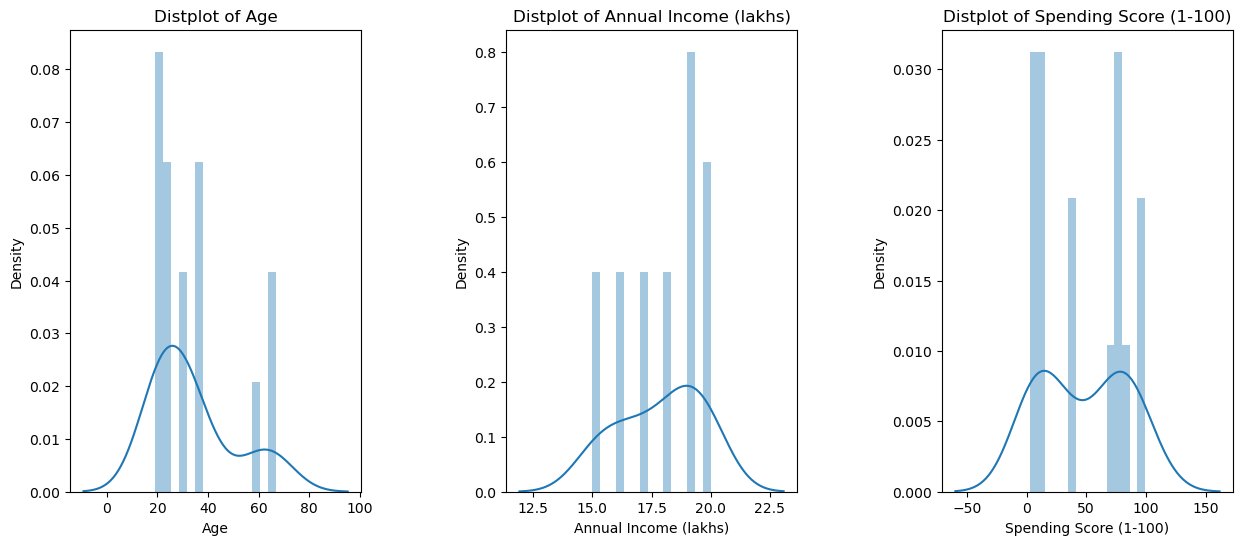

In [8]:
# check the distribution of these features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(1 , figsize = (15 , 6))
n = 0 
for x in ['Age' , 'Annual Income (lakhs)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 15)
    plt.title('Distplot of {}'.format(x))
plt.show()

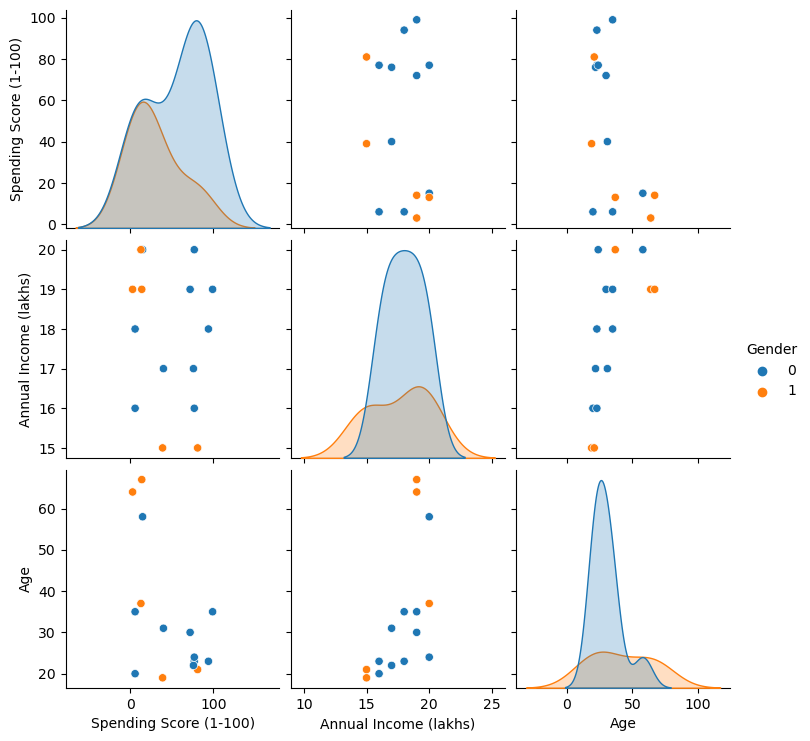

In [9]:
sns.pairplot(df, vars = ['Spending Score (1-100)', 'Annual Income (lakhs)', 'Age'], hue = "Gender")

In [26]:
# Kmeans clustering with help of SC for selection of number of clusters
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import silhouette_samples, silhouette_score


range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
max_avg = -1
best_k = 0

for n_clusters in range_n_clusters:
    # cluster and predict
    clusterer = BisectingKMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # keep the maximum average and the corresponding clustering
    if silhouette_avg > max_avg:
        best_k = n_clusters
        max_avg = silhouette_avg


print(best_k)

For n_clusters = 2 The average silhouette_score is : 0.6436718566338571
For n_clusters = 3 The average silhouette_score is : 0.42388719712886674
For n_clusters = 4 The average silhouette_score is : 0.5150108812256536
For n_clusters = 5 The average silhouette_score is : 0.4324680498373928
For n_clusters = 6 The average silhouette_score is : 0.3966808959518546
For n_clusters = 7 The average silhouette_score is : 0.4703349805799876
For n_clusters = 8 The average silhouette_score is : 0.2663611311048345
2


In [20]:
# Kmeans clustering with help of CHI for selection of number of clusters
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import calinski_harabasz_score


range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
max_avg = -10000
best_k = 0

for n_clusters in range_n_clusters:
    # cluster and predict
    clusterer = BisectingKMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    calinski_avg = calinski_harabasz_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        calinski_avg,
    )
    # keep the maximum average and the corresponding clustering
    if calinski_avg > max_avg:
        best_k = n_clusters
        max_avg = calinski_avg


print(best_k)

For n_clusters = 2 The average silhouette_score is : 44.982132488106366
For n_clusters = 3 The average silhouette_score is : 26.379545111948573
For n_clusters = 4 The average silhouette_score is : 36.49992420197075
For n_clusters = 5 The average silhouette_score is : 33.86127839913329
For n_clusters = 6 The average silhouette_score is : 42.100718132854574
For n_clusters = 7 The average silhouette_score is : 83.85472597818277
For n_clusters = 8 The average silhouette_score is : 72.24594215108117
7


In [21]:
# Kmeans clustering with help of CHI for selection of number of clusters
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import davies_bouldin_score


range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
min_avg = 10000
best_k = 0

for n_clusters in range_n_clusters:
    # cluster and predict
    clusterer = BisectingKMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    davies_avg = davies_bouldin_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        davies_avg,
    )
    # keep the maximum average and the corresponding clustering
    if davies_avg < min_avg:
        best_k = n_clusters
        min_avg = davies_avg


print(best_k)

For n_clusters = 2 The average silhouette_score is : 0.45765012567100527
For n_clusters = 3 The average silhouette_score is : 1.373572460239143
For n_clusters = 4 The average silhouette_score is : 0.6046891514533999
For n_clusters = 5 The average silhouette_score is : 0.6623649075727036
For n_clusters = 6 The average silhouette_score is : 0.6619767334175213
For n_clusters = 7 The average silhouette_score is : 0.3807437506034309
For n_clusters = 8 The average silhouette_score is : 0.3920335612891669
7


In [27]:
# use bisecting KMeans
from sklearn.cluster import BisectingKMeans
bisect_means = BisectingKMeans(n_clusters=best_k).fit(X)
bisect_means.labels_

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], dtype=int32)

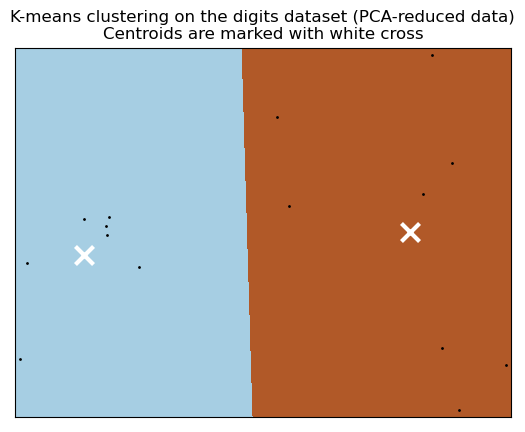

In [28]:
# use reduced data dim with PCA
from sklearn.decomposition import PCA
import numpy as np

reduced_data = PCA(n_components=2).fit_transform(X)
kmeans = BisectingKMeans(n_clusters=best_k)
kmeans.fit(reduced_data)

h = 0.02
# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()


In [29]:
# train a KMeans model with best_k
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=best_k).fit(X)
kmeans.labels_

/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1], dtype=int32)

/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


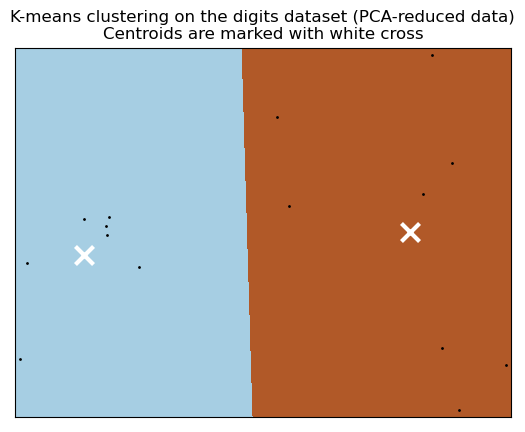

In [30]:
# use reduced data dim with PCA
from sklearn.decomposition import PCA
reduced_data = PCA(n_components=2).fit_transform(X)
kmeans = KMeans(n_clusters=best_k)
kmeans.fit(reduced_data)

h = 0.02
# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()


/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_in

Text(0, 0.5, 'Inertia')

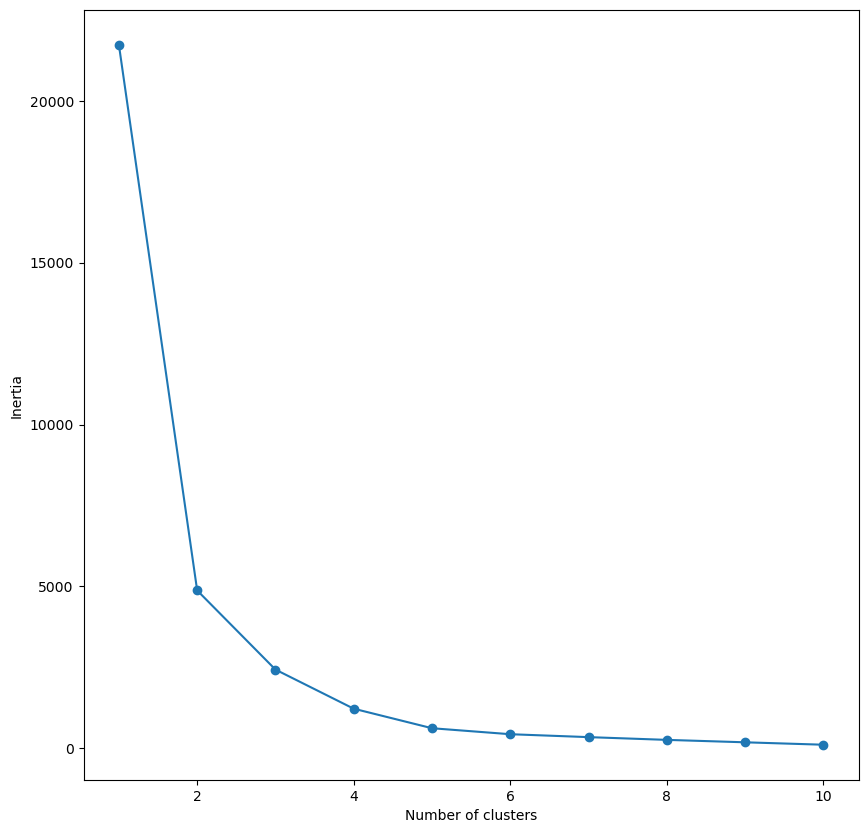

In [32]:
SSE = []
for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(X)
    SSE.append(kmeans.inertia_)# converting the results into a dataframe and plotting them
frame = pd.DataFrame({'Cluster':range(1,11), 'SSE':SSE})
plt.figure(figsize=(10, 10))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [39]:
kmeans_new = KMeans(n_clusters=2)
#Fit the data
kmeans_new.fit(X)
#Create a new data frame with the predicted clusters
clusters_new = X.copy()
clusters_new['cluster_pred'] = kmeans_new.labels_

/usr/lib/python3/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [31]:
avg_data = clusters_new.groupby([‘cluster_pred’], as_index=False).mean()
print(avg_data)

sns.barplot(x='cluster_pred',y='Age',palette="plasma",data=avg_data)

NameError: name 'avg_data' is not defined

In [ ]:
sns.barplot(x='cluster_pred',y='Annual Income (k$)',palette="plasma",data=avg_data)
sns.barplot(x='cluster_pred',y='Spending Score (1-100)',palette="plasma",data=avg_data)